In [1]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

Saving q2_customers.csv to q2_customers.csv


In [2]:
# Data Preparation

df = pd.read_csv(io.BytesIO(uploaded['q2_customers.csv']))

In [4]:
# Scaling

X=df
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

Scaling is important before using K-means because it groups data based on distance. In the data, annual spend values are much larger than age values. If you don’t scale the data, spend will have a bigger influence on the clusters, and age will mostly be ignored. This can lead to biased clusters and poor business insights. By scaling the data first, all features are treated equally, helping K-means create more meaningful and accurate clusters.

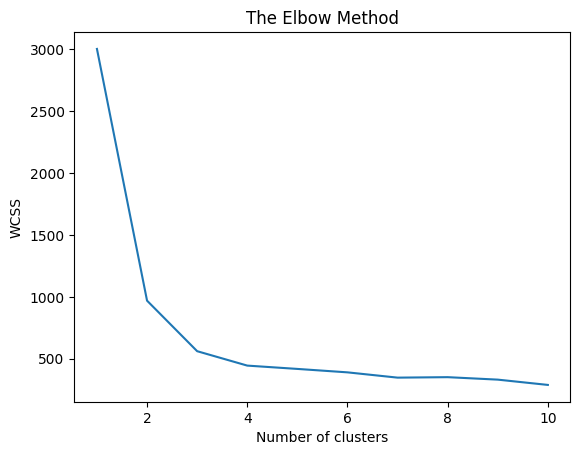

In [5]:
# Choosing K — Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Using the elbow method, we found that the best value of K is 3. The graph shows a sharp drop in the WCSS value from 1 to 2 and from 2 to 3. After K = 3, the curve becomes almost flat.

In [6]:
# K-means Clustering

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)
df['Cluster'] = y_kmeans
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,Cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [10]:
# Inverse-transform centroids back to original feature scale for readability

features = ['age', 'annual_spend', 'visits_per_month',
            'basket_size', 'days_since_last_visit', 'num_categories_purchased']

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=features,
    index=[f'Cluster {i}' for i in range(3)]
).round(2)

print("Cluster Centroids (original scale):\n")
centroids_df

Cluster Centroids (original scale):



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster 0,24.68,14847.37,14.34,558.97,9.08,2.11
Cluster 1,56.77,89413.33,2.53,5530.55,105.36,7.52
Cluster 2,40.39,43340.73,8.19,2021.68,35.19,4.42


**Clusters' Interpretations**

*   Cluster 0 - Young Frequent Low-Spenders
*   Cluster 1 - Older High-Value Lapsed Shoppers
*   Cluster 2 - Mid-Life Core Shoppers





In [11]:
# Dimensionality Reduction using PCA

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [12]:
#Explained variance ratio for Each PCA components

explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio for Each PCA Component:", explained_variance)

Explained Variance Ratio for Each PCA Component: [0.83560354 0.05568764]


In [13]:
#Print the feature loadings (components) as a readable dataframe

components = pca.components_
components_df = pd.DataFrame(components, columns=df.columns[:-1])  # Exclude 'Cluster' column
print("Feature Loadings (Components):")
print(components_df)

Feature Loadings (Components):
        age  annual_spend  visits_per_month  basket_size  \
0  0.411569       0.42154         -0.410399     0.412012   
1 -0.259432      -0.03327          0.208318    -0.195402   

   days_since_last_visit  num_categories_purchased  
0               0.378582                  0.414017  
1               0.911194                 -0.140479  


PC1 (Component 0): Distinguishes high-spending, larger-basket but less frequent shoppers from frequent, lower-spending shoppers.

PC2 (Component 1): Mainly captures recency, separating inactive customers (long time since last visit) from recent/active customers.

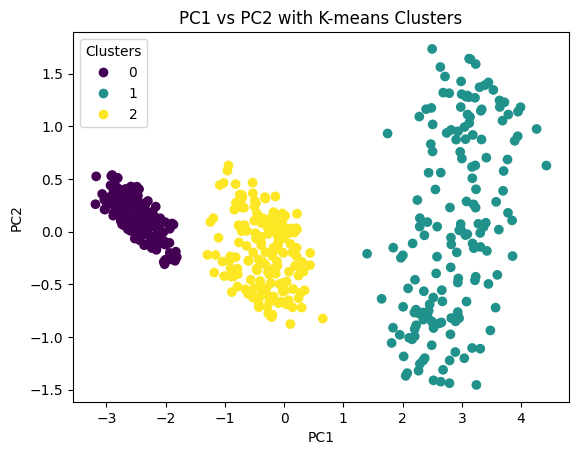

In [19]:
#Cluster Visualization

scatter=plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans,cmap='viridis')
plt.title('PC1 vs PC2 with K-means Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
handles, labels = scatter.legend_elements()
plt.legend(handles, labels, title="Clusters")
plt.show()